In [20]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

# --- Step 1: Define cluster sizes ---
num_clusters = 10
nodes_per_cluster = 200
sizes = [nodes_per_cluster] * num_clusters  # total 200 nodes

# --- Step 2: Define connection probabilities ---
# High intra-cluster probability, low inter-cluster
p_intra = 0.5
p_inter = 0.005

# Create a block probability matrix
probs = np.full((num_clusters, num_clusters), p_inter)
np.fill_diagonal(probs, p_intra)

# --- Step 3: Generate the graph using SBM ---
G = nx.stochastic_block_model(sizes, probs, seed=42)

# --- Step 4: Get layout and draw ---
# Color by cluster (block)
colors = [G.nodes[i]['block'] for i in G.nodes()]
pos = nx.spring_layout(G, seed=42)  # Fruchterman–Reingold

In [28]:
probs

array([[0.5  , 0.005, 0.005, 0.005, 0.005, 0.005, 0.005, 0.005, 0.005,
        0.005],
       [0.005, 0.5  , 0.005, 0.005, 0.005, 0.005, 0.005, 0.005, 0.005,
        0.005],
       [0.005, 0.005, 0.5  , 0.005, 0.005, 0.005, 0.005, 0.005, 0.005,
        0.005],
       [0.005, 0.005, 0.005, 0.5  , 0.005, 0.005, 0.005, 0.005, 0.005,
        0.005],
       [0.005, 0.005, 0.005, 0.005, 0.5  , 0.005, 0.005, 0.005, 0.005,
        0.005],
       [0.005, 0.005, 0.005, 0.005, 0.005, 0.5  , 0.005, 0.005, 0.005,
        0.005],
       [0.005, 0.005, 0.005, 0.005, 0.005, 0.005, 0.5  , 0.005, 0.005,
        0.005],
       [0.005, 0.005, 0.005, 0.005, 0.005, 0.005, 0.005, 0.5  , 0.005,
        0.005],
       [0.005, 0.005, 0.005, 0.005, 0.005, 0.005, 0.005, 0.005, 0.5  ,
        0.005],
       [0.005, 0.005, 0.005, 0.005, 0.005, 0.005, 0.005, 0.005, 0.005,
        0.5  ]])

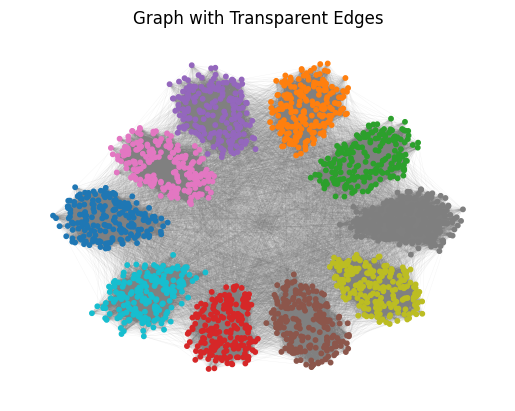

In [ ]:
# Draw nodes (fully opaque)
nx.draw_networkx_nodes(G, pos, node_color=colors, cmap=plt.cm.tab10, node_size=10)

# Draw edges (transparent)
nx.draw_networkx_edges(G, pos, edge_color='gray', alpha=0.1, width=0.25)

plt.title("Graph with Transparent Edges")
plt.axis('off')
plt.show()

In [ ]:
A = nx.adjacency_matrix(G)
A_dense = A.toarray()  # or A.todense()
A_weighted = nx.adjacency_matrix(G, weight='weight').toarray()

In [35]:
import networkx as nx

# Define sizes of each block (community)
sizes = [300, 300, 400]  # 3 communities with 30, 30, and 40 nodes

# Define intra- and inter-community connection probabilities
# This is a 3x3 matrix corresponding to block-to-block connection probs
p = [
    [0.3, 0.005, 0.002],   # Community 0 to 0/1/2
    [0.005, 0.25, 0.004],  # Community 1 to 0/1/2
    [0.002, 0.004, 0.2]    # Community 2 to 0/1/2
]

# Generate the stochastic block model graph
G = nx.stochastic_block_model(sizes, p)
import random

for (u, v) in G.edges():
    # Simple: weight from uniform distribution
    G[u][v]['weight'] = random.uniform(0.1, 1.0)


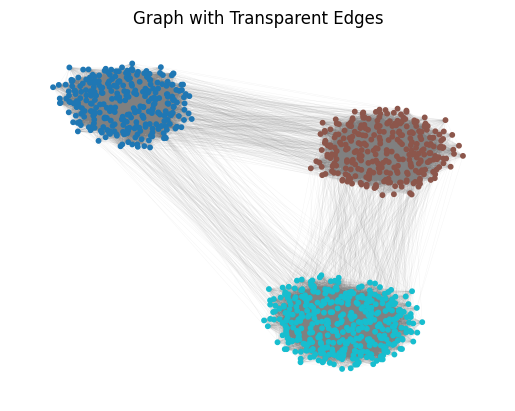

In [36]:
# Draw nodes (fully opaque)
colors = [G.nodes[i]['block'] for i in G.nodes()]
pos = nx.spring_layout(G, seed=42)  # Fruchterman–Reingold

nx.draw_networkx_nodes(G, pos, node_color=colors, cmap=plt.cm.tab10, node_size=10)

# Draw edges (transparent)
nx.draw_networkx_edges(G, pos, edge_color='gray', alpha=0.1, width=0.25)

plt.title("Graph with Transparent Edges")
plt.axis('off')
plt.show()

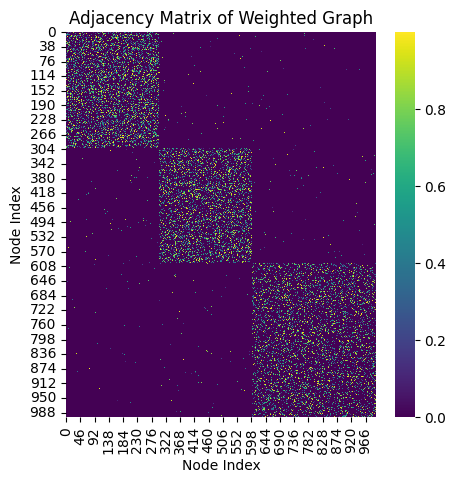

In [41]:
A_weighted = nx.adjacency_matrix(G, weight='weight').toarray()

# visualize the adjacency matrix
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(5, 5))
sns.heatmap(A_weighted, cmap='viridis', cbar=True)
plt.title("Adjacency Matrix of Weighted Graph")
plt.xlabel("Node Index")
plt.ylabel("Node Index")
plt.show()

In [42]:
import numpy as np

# Sizes of blocks
sizes = [30, 30, 40]
n = sum(sizes)
num_blocks = len(sizes)

# Connection probability matrix (ground-truth)
p = [
    [0.3, 0.05, 0.02],
    [0.05, 0.25, 0.04],
    [0.02, 0.04, 0.2]
]

# Create block membership list
block_labels = []
for i, size in enumerate(sizes):
    block_labels.extend([i] * size)

# Initialize true weight matrix
W_true = np.zeros((n, n))

# Assign expected weights based on block memberships
for u in range(n):
    for v in range(n):
        block_u = block_labels[u]
        block_v = block_labels[v]
        W_true[u, v] = p[block_u][block_v]


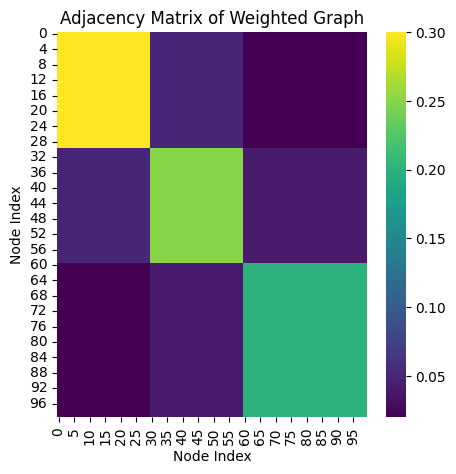

In [43]:
A_weighted = nx.adjacency_matrix(G, weight='weight').toarray()

# visualize the adjacency matrix
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(5, 5))
sns.heatmap(W_true, cmap='viridis', cbar=True)
plt.title("Adjacency Matrix of Weighted Graph")
plt.xlabel("Node Index")
plt.ylabel("Node Index")
plt.show()

In [ ]:
import pandas as pd
import torch
from tqdm import tqdm
from torchmetrics import AUROC
import torch.nn.functional as F
from torch.distributions import Bernoulli
BCE = F.binary_cross_entropy
auroc = AUROC(task="binary")
verbose = True
gpuid = 0

data = torch.tensor(pd.read_csv('MetData.csv').values, device=f'cuda:{gpuid}', dtype=torch.float32)
N, P = data.shape
subsets = []
leftovers = []
n_rhos = 100

for i in range(P):
    # Mask to remove i-th column
    mask = torch.ones(P, dtype=torch.bool)
    mask[i] = False
    subset = data[:, mask] # shape: (N, P-1)
    # add a one column to the subset
    subset = torch.cat((subset, torch.ones(N, 1, device=f'cuda:{gpuid}')), dim=1) # shape: (N, P)
    leftover = data[:, i].unsqueeze(1) # shape: (N, 1)

    subsets.append(subset.unsqueeze(2)) # shape: (N, P-1, 1)
    leftovers.append(leftover.unsqueeze(2)) # shape: (N, 1, 1)

inputs = torch.cat(subsets, dim=2) # shape: (N, P-1, P)
labels = torch.cat(leftovers, dim=2) # shape: (N, 1, P)
labels = labels.expand(-1, n_rhos, -1) # shape: (N, n_rhos, P)

# Compute rho_max = max(|X^T y|) / n
rho_min_ratio = 1e-3 if N > P else 1e-2
rho_seqs = []
for i in range(P):
    labels_ = labels[:, 0, i] # shape: (N,)
    inputs_ = inputs[:, :, i] # shape: (N, P-1)
    rho_max = inputs_.T @ (labels_-0.5) # shape: (P-1,)
    rho_max = torch.max(torch.abs(rho_max))/N
    rho_sequence = torch.logspace(
        start=torch.log10(rho_max),
        end=torch.log10(rho_max * rho_min_ratio),
        steps=n_rhos,
    )
    rho_seqs.append(rho_sequence)
rho_seqs = torch.stack(rho_seqs, dim=1) # shape: (n_rhos, P)

def trainer(parameters, optim, closure, verbose=True, epochs=1000):
    pbar = tqdm(range(epochs)) if verbose else range(epochs)
    loss = closure()

    for iteration in pbar:
        previous_parameters = [p.clone().detach() for p in parameters]
        previous_loss = loss.detach()

        loss = optim.step(closure)

        d_loss = (previous_loss - loss).item()
        d_parameters = sum(
            torch.norm(prev - curr, p=2).item()
            for prev, curr in zip(previous_parameters, parameters)
        )
        grad_norm = torch.norm(W.grad, p=2).item()
        if verbose:
            pbar.set_postfix({
                "loss": loss.item(),
                "grad_norm": grad_norm,
                "d_parameter": d_parameters,
                "d_loss": d_loss
            })
        eps = 1e-5
        if d_loss < eps and d_parameters < eps and grad_norm < eps:
            break

    return parameters

step_size = 64
for i in tqdm(range(0, P, step_size)):
    B = min(step_size, P - i)
    W = torch.randn((P, n_rhos, B), device=f'cuda:{gpuid}', requires_grad=True)
    optimizer = torch.optim.LBFGS([W], lr=0.01, max_iter=1000, history_size=10, line_search_fn='strong_wolfe')

    inputs_ = inputs[:, :, i:i+B].to(f'cuda:{gpuid}')
    labels_ = labels[:, :, i:i+B].to(f'cuda:{gpuid}')
    rho_seqs_ = rho_seqs[:, i:i+B].to(f'cuda:{gpuid}')

    def closure():
        optimizer.zero_grad()
        logits = torch.einsum('ijp,jkp->ikp', inputs_, W) # shape: (N, n_rhos, P)
        probs = torch.sigmoid(logits)
        loss = -Bernoulli(probs=probs).log_prob(labels_) # shape: (N, n_rhos, P)
        loss = loss.mean(dim=0) + rho_seqs_ * torch.norm(W, p=1, dim=0) # >> shape: (n_rhos, P)
        loss = loss.mean()
        loss.backward()
        return loss

    W = trainer([W], optimizer, closure, verbose=False)[0]
    logits = torch.einsum('ijp,jkp->ikp', inputs_, W) # shape: (N, n_rhos, P)
    auc = auroc(torch.sigmoid(logits), labels_)
    print(f"AUC: {auc.item()}")

mkdir -p failed for path /afs/cs.stanford.edu/u/sttruong/.config/matplotlib: [Errno 13] Permission denied: '/afs/cs.stanford.edu/u/sttruong/.config/matplotlib'
Matplotlib created a temporary cache directory at /tmp/user/21130/matplotlib-kh223q53 because there was an issue with the default path (/afs/cs.stanford.edu/u/sttruong/.config/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


OutOfMemoryError: CUDA out of memory. Tried to allocate 20.00 MiB. GPU 0 has a total capacity of 79.15 GiB of which 10.19 MiB is free. Process 1165439 has 414.00 MiB memory in use. Process 1992227 has 69.13 GiB memory in use. Including non-PyTorch memory, this process has 9.58 GiB memory in use. Of the allocated memory 8.31 GiB is allocated by PyTorch, and 808.40 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)